In [1]:
!pip install ultralytics torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import gdown
import cv2 as cv
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import gdown

Descarga del dataset

In [ ]:
id = "1ceJy2Vl1tzDnlDj9k7mlYd64M7hnh9dk"
output = "dataset_v1.zip"

gdown.download(id=id, output=output, quiet=False)

!unzip -q dataset_v1.zip -d /content/dataset

Downloading...
From (original): https://drive.google.com/uc?id=1ceJy2Vl1tzDnlDj9k7mlYd64M7hnh9dk
From (redirected): https://drive.google.com/uc?id=1ceJy2Vl1tzDnlDj9k7mlYd64M7hnh9dk&confirm=t&uuid=e53c756d-b9bd-4a26-8b8d-f9d256457211
To: /content/dataset_v1.zip
100%|██████████| 405M/405M [00:02<00:00, 173MB/s]


In [ ]:
data_path = '/content/dataset/valorant-char-detection.v2i.yolov11/data.yaml'

Descarga del modelo YOLO11s.pt

In [ ]:
file_id = "1QYZnQWg9300hWQ3J6S1OEztKt52iqsJg"
output_folder = "/content/models"
output_path = f"{output_folder}/yolo11s.pt"

os.makedirs(output_folder, exist_ok=True)

gdown.download(id=file_id, output=output_path, quiet=False)

print(f"Modelo descargado en: {output_path}")

Downloading...
From: https://drive.google.com/uc?id=1QYZnQWg9300hWQ3J6S1OEztKt52iqsJg
To: /content/models/yolo11s.pt
100%|██████████| 19.3M/19.3M [00:00<00:00, 219MB/s]

Modelo descargado en: /content/models/yolo11s.pt


# Small

In [ ]:
small_path = '/content/models/yolo11s.pt'

# Primera versión

## Entrenamiento

In [ ]:
small = YOLO(small_path)

train_results = small.train(
    data=data_path,
    epochs=200,
    imgsz=640,
    device=0,
)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v2i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/1.CV/models/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False

In [ ]:
best_path = "/content/runs/detect/train/weights/best.pt"

## Validación

In [ ]:
best_small = YOLO(best_path)

metrics = best_small.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 15.3±33.2 ms, read: 45.2±35.6 MB/s, size: 202.8 KB)
val: Scanning /content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v2i.yolov11/valid/labels.cache... 240 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 284.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.1it/s 13.5s
                   all        240        241      0.965       0.91      0.964      0.794
                   iso         23         23      0.947      0.913       0.94      0.757
                  jett         31         31      0.903      0.968      0.976      0.836
                  neon         34         34      0.991      0.912      0.975      0.746
               phoenix         25         26      0.988      0.808       0.93

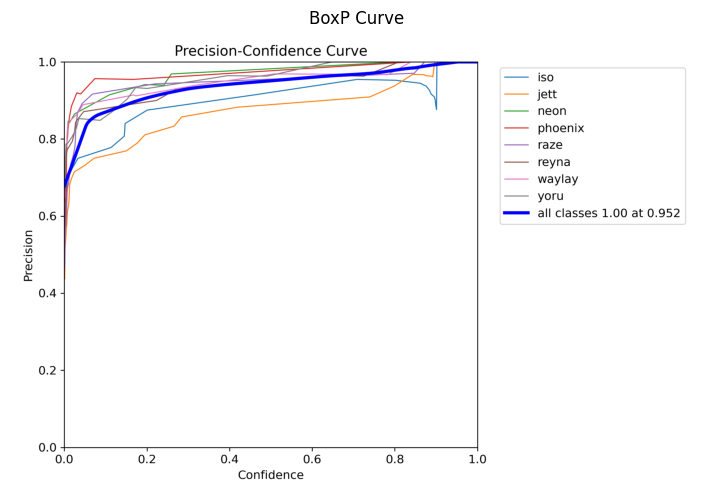

In [ ]:
image_path = '/content/runs/detect/val/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxP Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

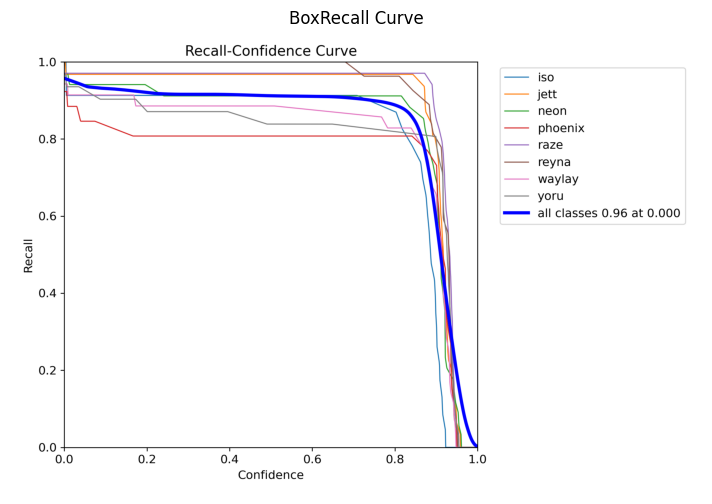

In [ ]:
image_path = '/content/runs/detect/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxRecall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

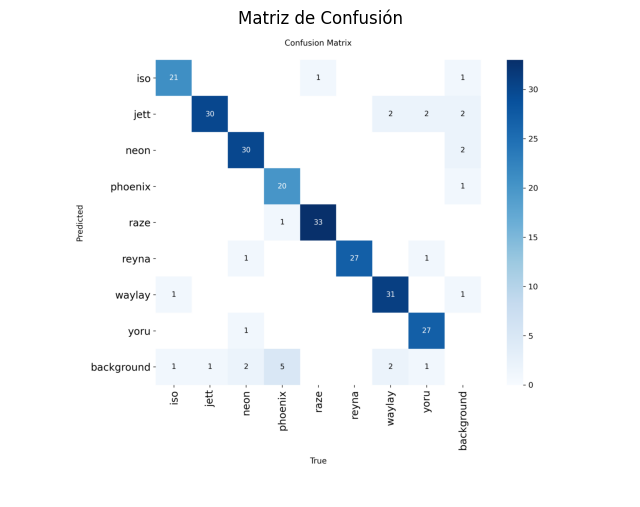

In [ ]:
image_path = '/content/runs/detect/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

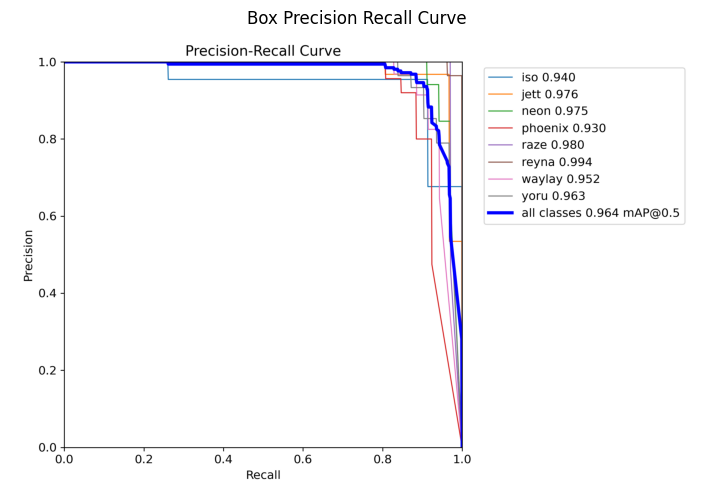

In [ ]:
image_path = '/content/runs/detect/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

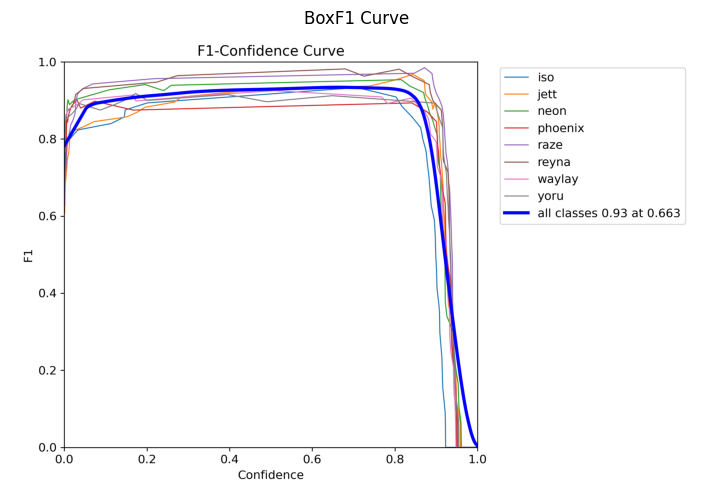

In [ ]:
image_path = '/content/runs/detect/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Visualización del conjunto de validación

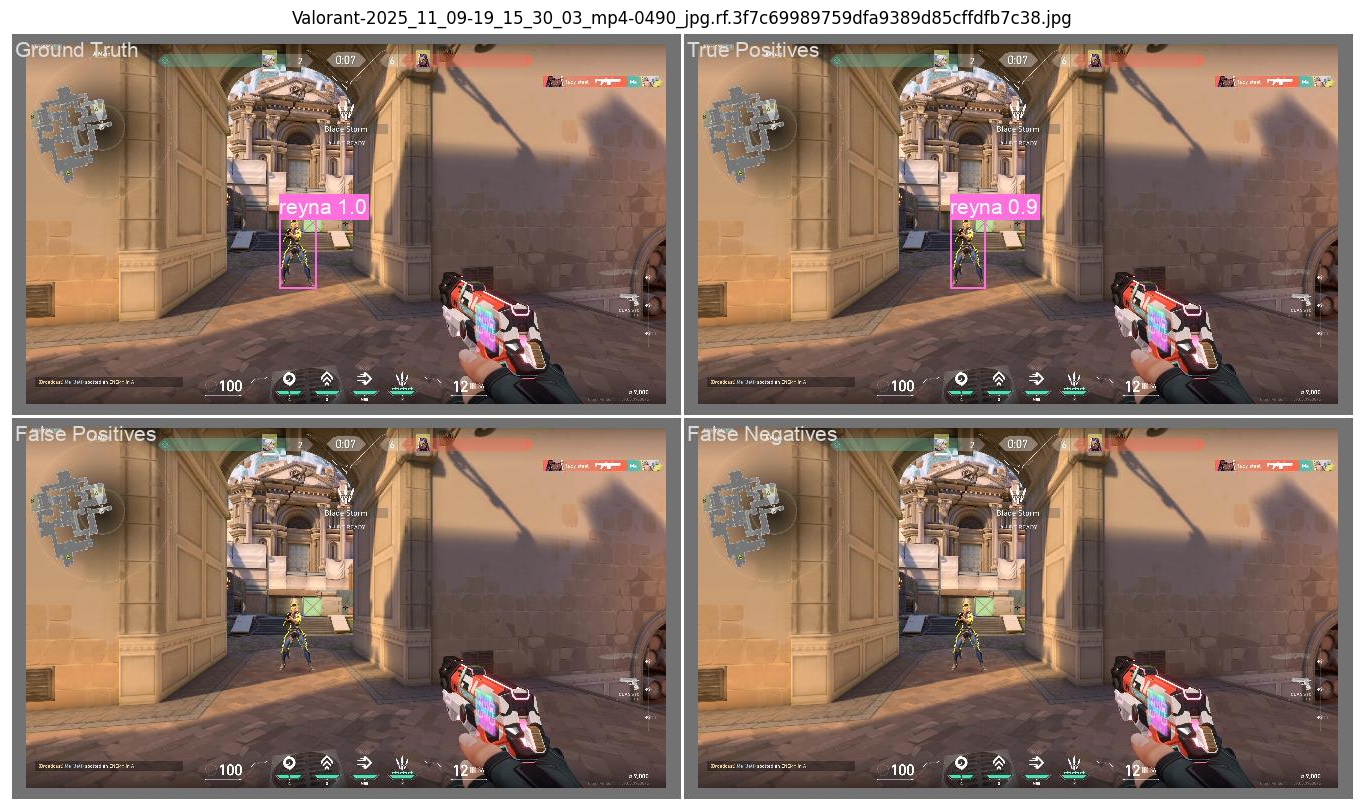

In [ ]:
# Ruta de la imagen específica que quieres mostrar
img_path = '/content/runs/detect/val/visualizations/Valorant-2025_11_09-19_15_30_03_mp4-0490_jpg.rf.3f7c69989759dfa9389d85cffdfb7c38.jpg'

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

In [ ]:
folder_path = '/content/drive/MyDrive/1.CV/dataset/videos/test/img/'

model = YOLO(best_path)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

print(f"{len(image_files)} imágenes.")

for img_name in image_files:
    full_path = os.path.join(folder_path, img_name)

    results = model(full_path)

    for r in results:
        print(f"\nProcesando: {img_name}")
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            print(f" - Clase: {model.names[cls_id]} | Confianza: {conf:.2f}")

        im_array = r.plot()
        im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb)
        plt.axis('off')
        plt.title(f'Detección: {img_name}')
        plt.show()

        save_name = f"result_{img_name}"
        cv.imwrite(save_name, im_array)

Output hidden; open in https://colab.research.google.com to view.

# Nueva version

In [ ]:
id = "14nVGy9lLE7lWK5k4VGmBfHSld4aZoVPD"
output = "dataset_v2.zip"

gdown.download(id=id, output=output, quiet=False)

!unzip -q dataset_v2.zip -d /content/dataset

Downloading...
From (original): https://drive.google.com/uc?id=14nVGy9lLE7lWK5k4VGmBfHSld4aZoVPD
From (redirected): https://drive.google.com/uc?id=14nVGy9lLE7lWK5k4VGmBfHSld4aZoVPD&confirm=t&uuid=0ab188f7-338a-4dc6-99c8-4739abb21059
To: /content/dataset_v2.zip
100%|██████████| 256M/256M [00:01<00:00, 159MB/s]


In [ ]:
data_path = '/content/dataset/valorant-char-detection.v3i.yolov11/data.yaml'

In [ ]:
small_path = '/content/models/yolo11s.pt'

## Entrenamiento

In [ ]:
small = YOLO(small_path)

train_results = small.train(
    data=data_path,
    epochs=200,
    imgsz=960,
    device=0,
    batch=16
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v3i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/1.CV/models/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=Fals

In [ ]:
best_path = "/content/runs/detect/train2/weights/best.pt"

## Validación

In [ ]:
best_small = YOLO(best_path)

metrics = best_small.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.4 ms, read: 50.5±12.7 MB/s, size: 84.2 KB)
val: Scanning /content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v3i.yolov11/valid/labels.cache... 313 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 313/313 361.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.2s/it 44.3s
                   all        313        415      0.945       0.88       0.94      0.743
                   iso         53         55          1       0.91      0.964      0.777
                  jett         53         53      0.876      0.906      0.931      0.742
                  neon         51         51      0.929      0.882      0.948      0.711
               phoenix         45         46      0.996      0.848      0.929   

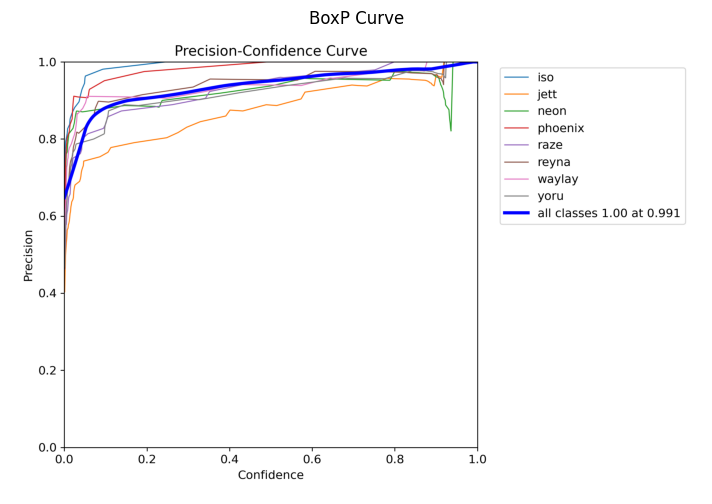

In [ ]:
image_path = '/content/runs/detect/val/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxP Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

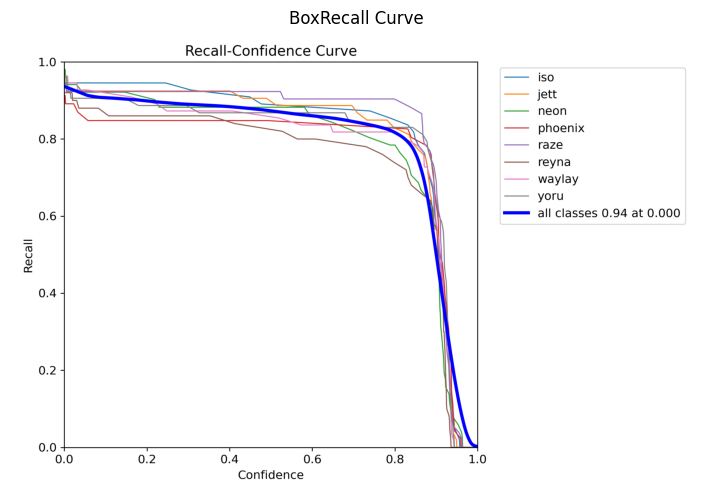

In [ ]:
image_path = '/content/runs/detect/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxRecall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

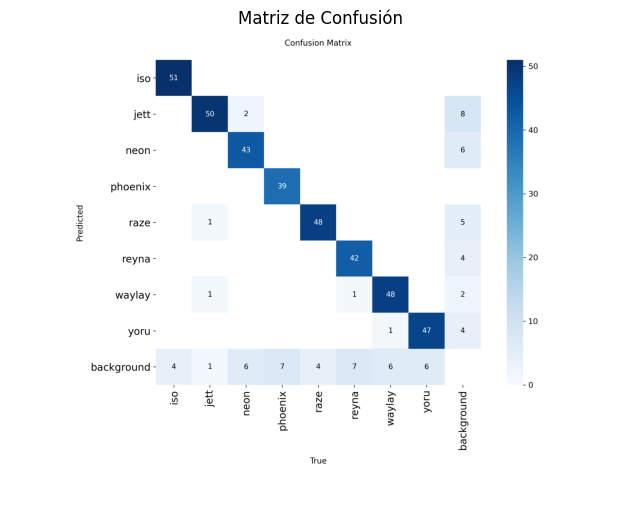

In [ ]:
image_path = '/content/runs/detect/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

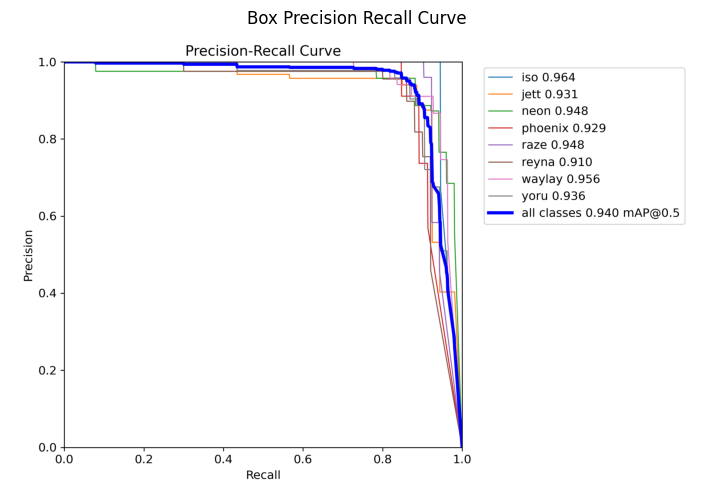

In [ ]:
image_path = '/content/runs/detect/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

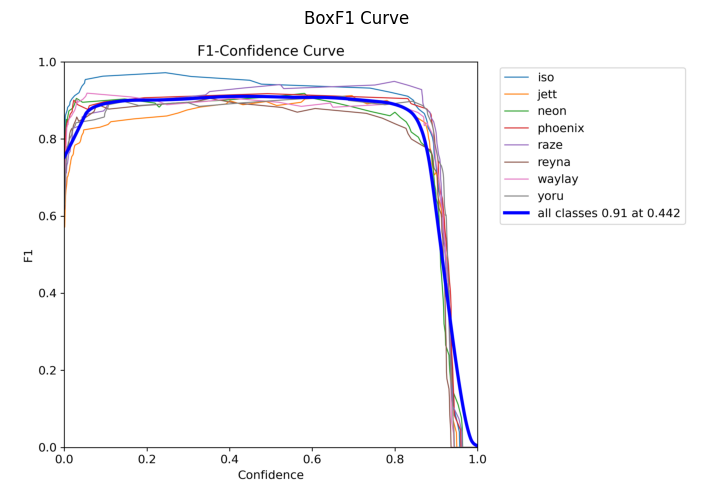

In [ ]:
image_path = '/content/runs/detect/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Visualizaciones del conjunto de validación

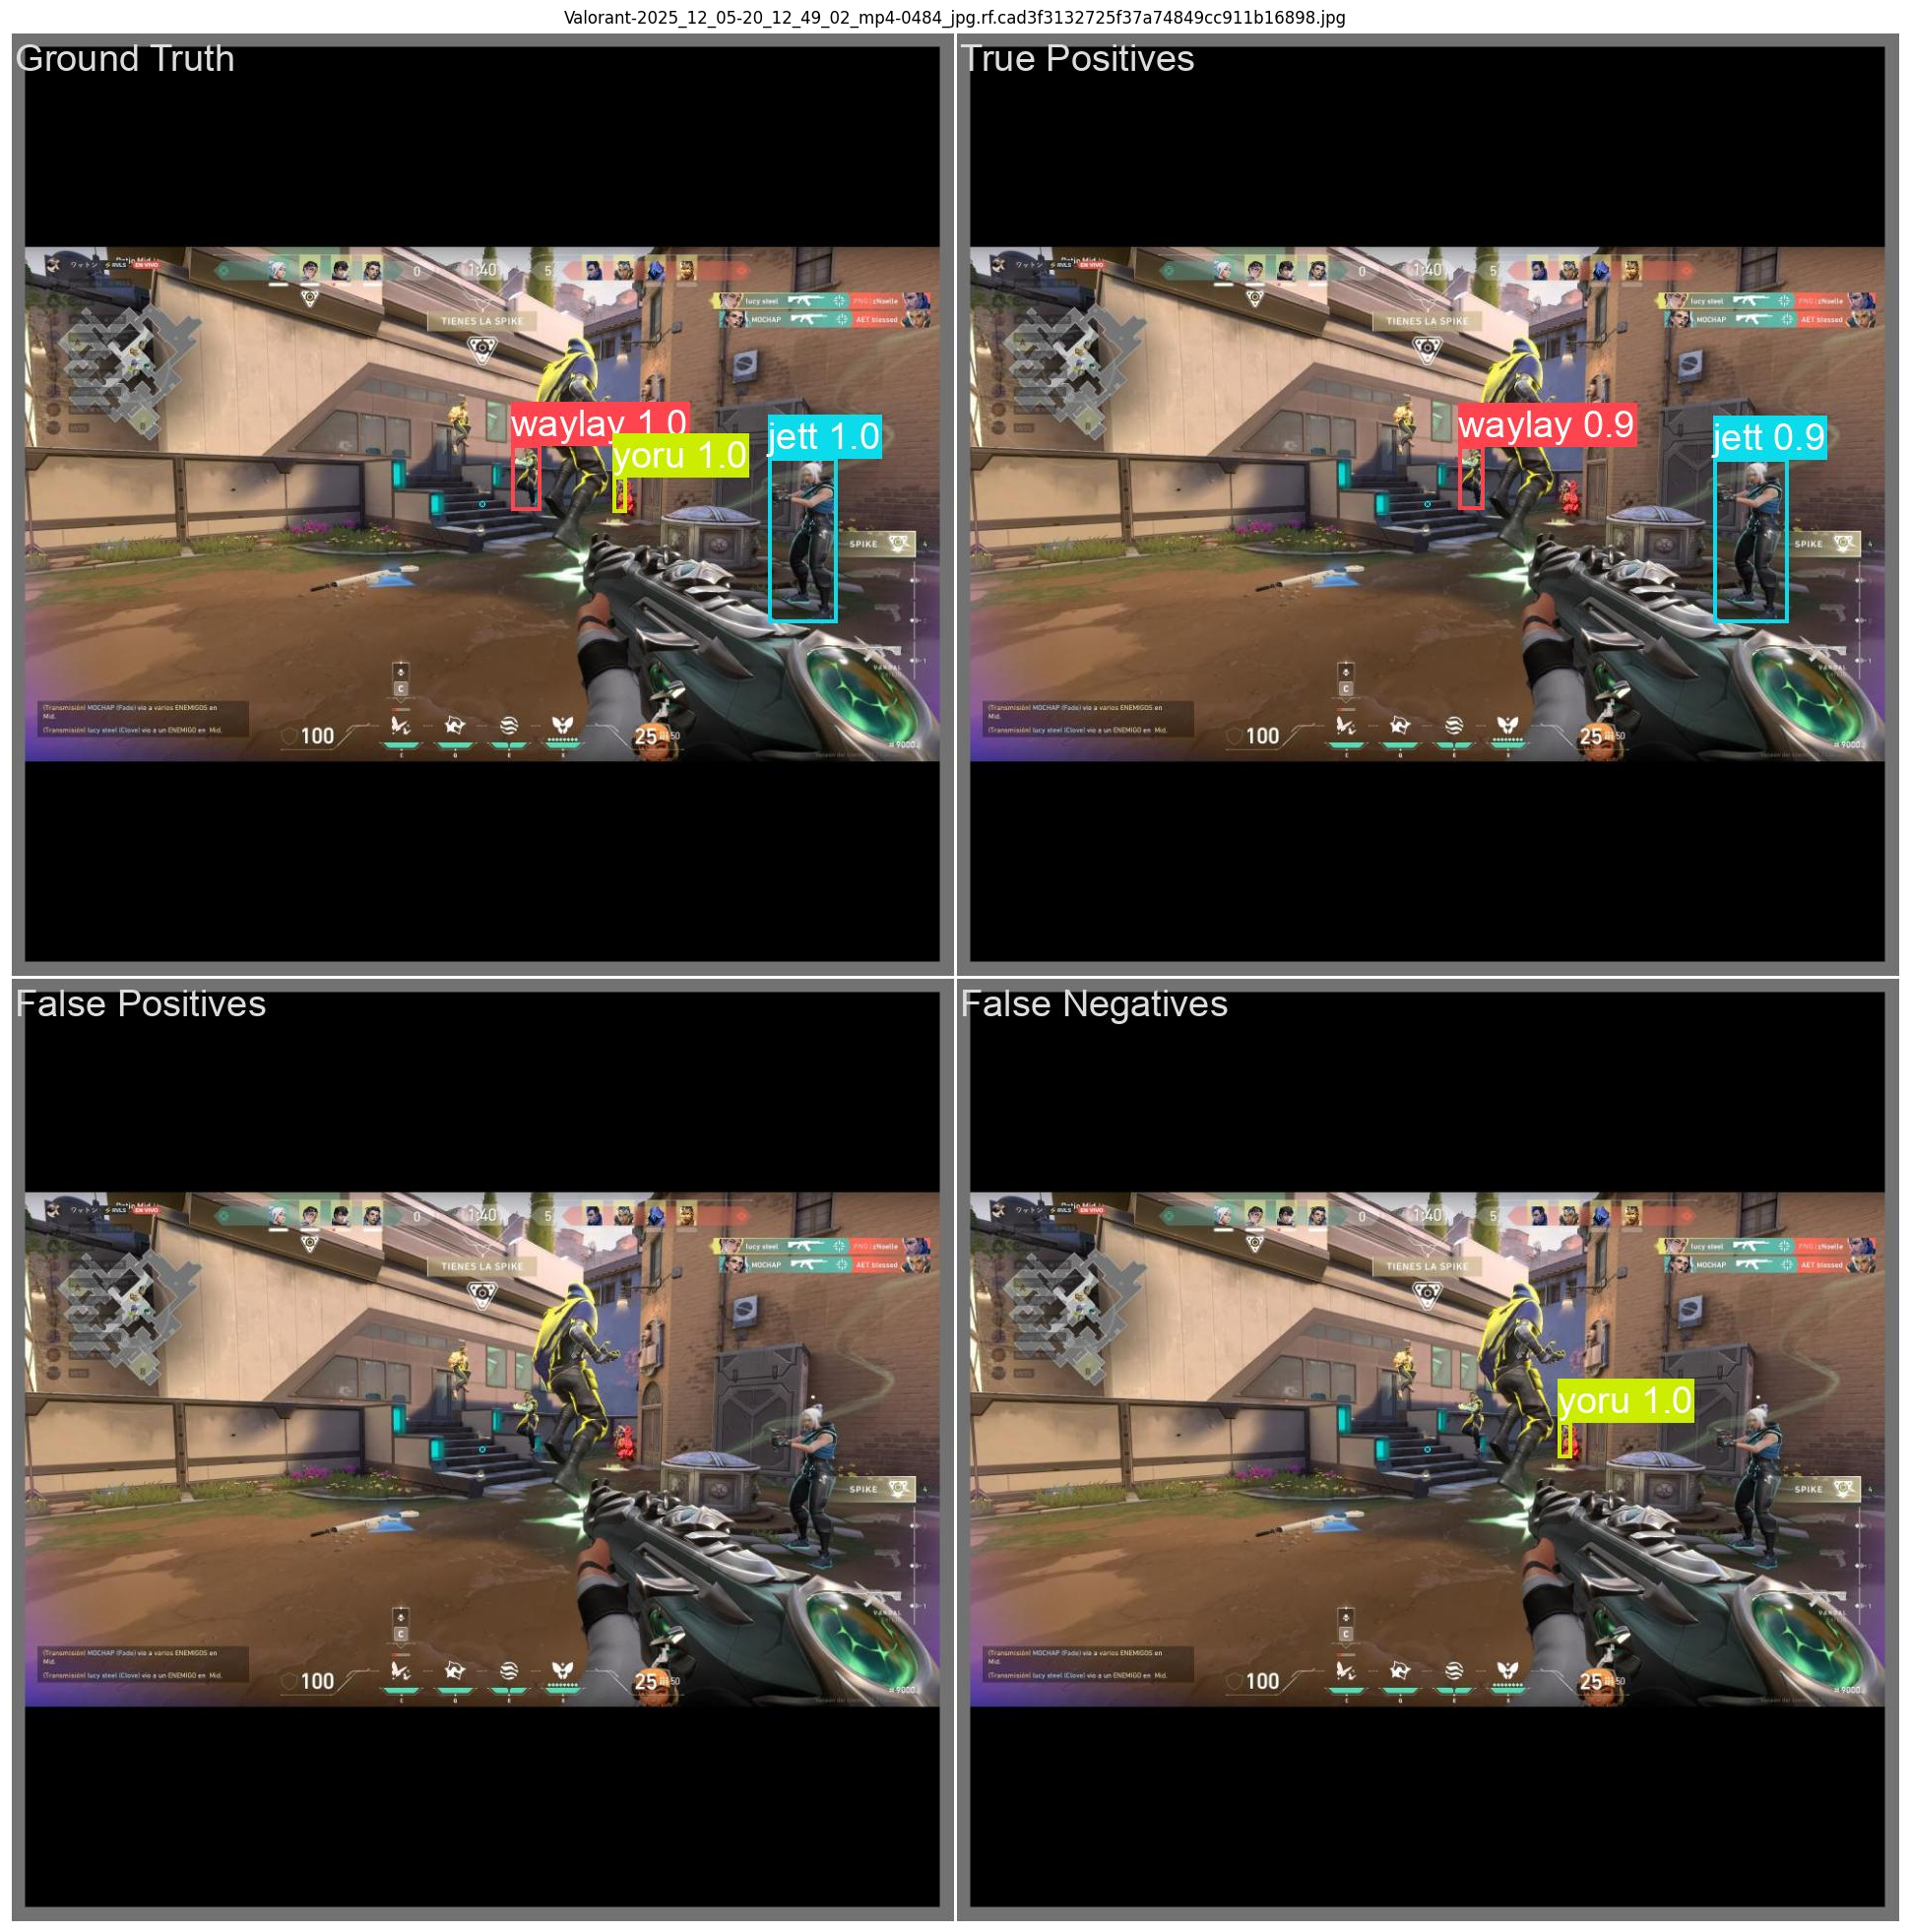

In [ ]:
# Ruta de la imagen específica que quieres mostrar
img_path = '/content/runs/detect/val/visualizations/Valorant-2025_12_05-20_12_49_02_mp4-0484_jpg.rf.cad3f3132725f37a74849cc911b16898.jpg'

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

## Prueba

In [ ]:
test_metrics = best_small.val(
    data=data_path,
    split="test",
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 0.2±0.0 MB/s, size: 86.5 KB)
val: Scanning /content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v3i.yolov11/test/labels... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 1.1it/s 55.7s
val: New cache created: /content/drive/MyDrive/1.CV/dataset/valorant-char-detection.v3i.yolov11/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.0s/it 12.2s
                   all         62         84        0.9      0.782       0.88      0.702
                   iso         11         11      0.974      0.636       0.78      0.661
                  jett          9          9          1       0.92      0.995      0.649
                  neon          8          8      0.704       0.75      0.829      0.646
               phoenix         10         10          1      0.685

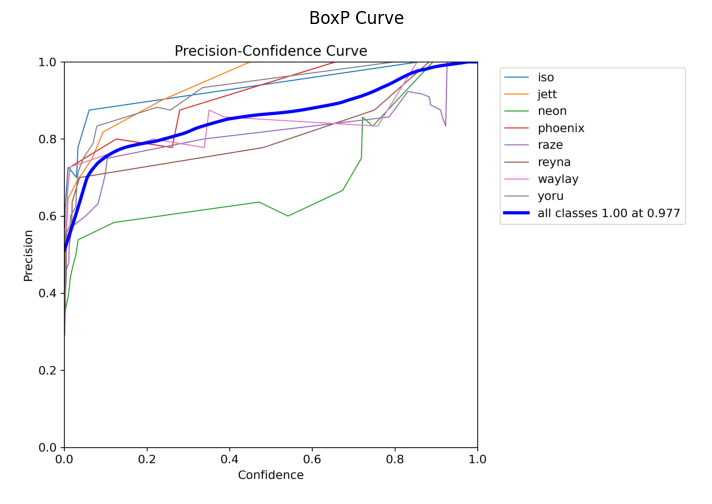

In [ ]:
image_path = '/content/runs/detect/val2/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxP Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

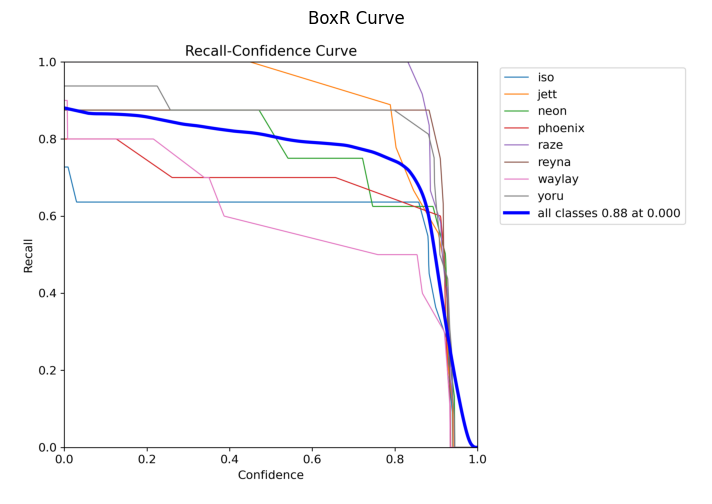

In [ ]:
image_path = '/content/runs/detect/val2/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxR Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

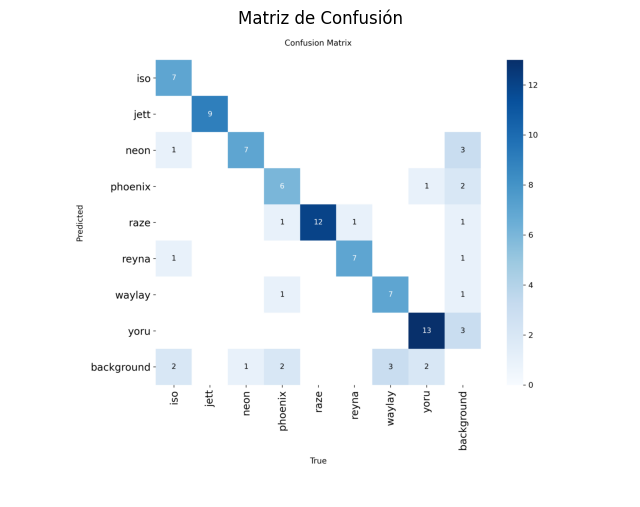

In [ ]:
image_path = '/content/runs/detect/val2/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

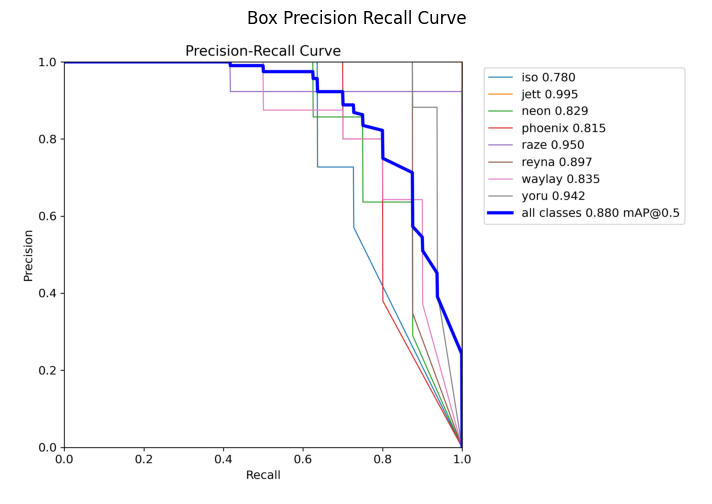

In [ ]:
image_path = '/content/runs/detect/val2/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

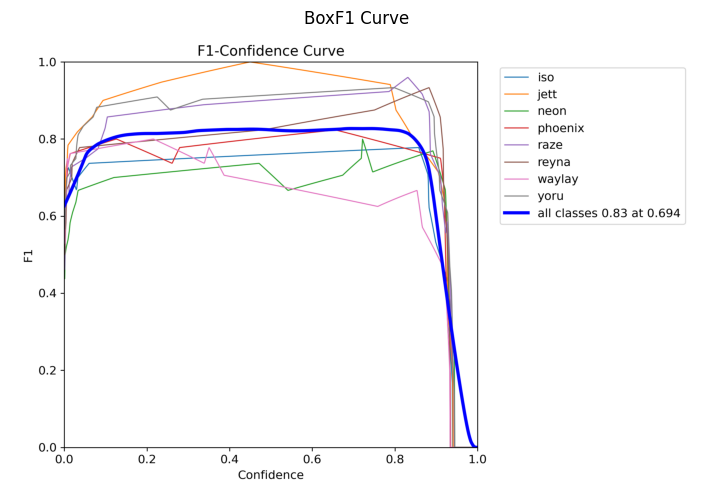

In [ ]:
image_path = '/content/runs/detect/val2/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Visualización del conjunto de prueba

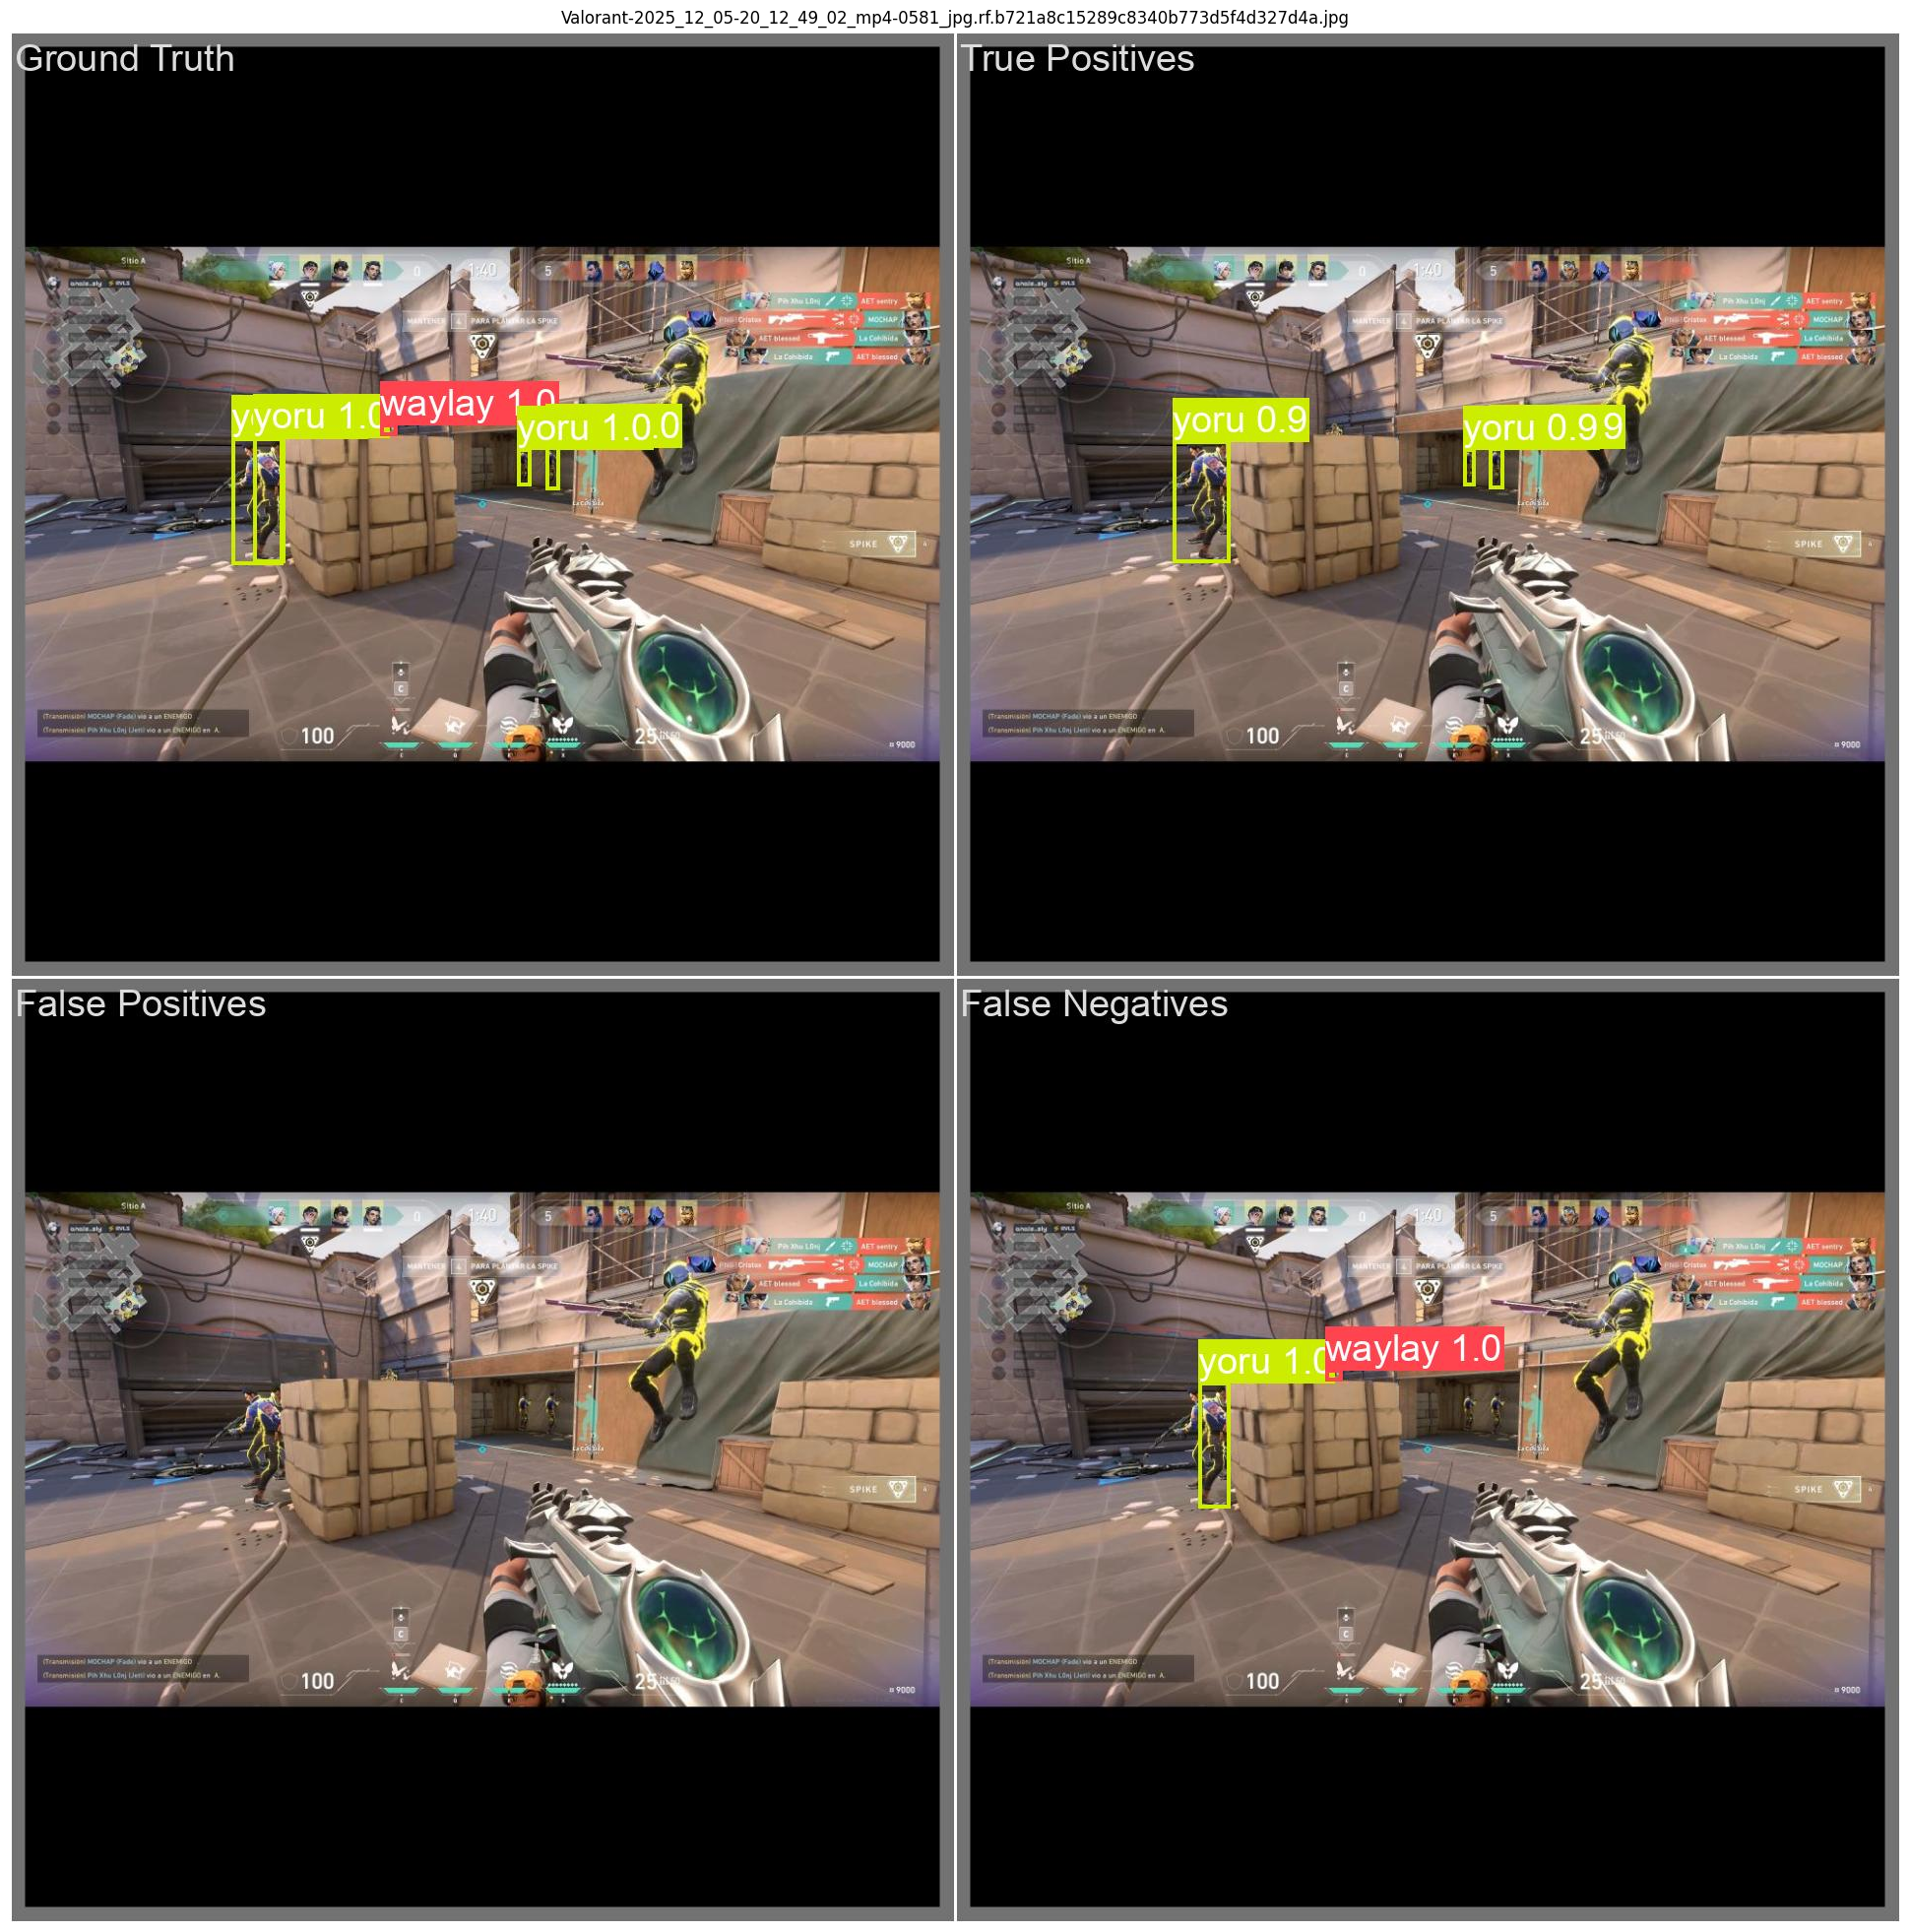

In [ ]:
# Ruta de la imagen específica que quieres mostrar
img_path = '/content/runs/detect/val2/visualizations/Valorant-2025_12_05-20_12_49_02_mp4-0581_jpg.rf.b721a8c15289c8340b773d5f4d327d4a.jpg'

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

In [ ]:
model_path = "/content/runs/detect/train2/weights/best.pt"

!yolo export model={model_path} format=onnx

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 100 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/1.CV/models/best/best2.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 12, 18900) (18.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 195ms
Prepared 6 packages in 1.37s
Installed 6 packages in 243ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnxruntime==1.23.2
 + onnxslim==0.1.78

requirements: AutoUpdate success ✅ 2.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: star

In [ ]:
# La inferencia se hizo por terminal con: yolo predict model=best2.pt source="sunset.mp4" save=True conf=0.75 line_width=2